In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

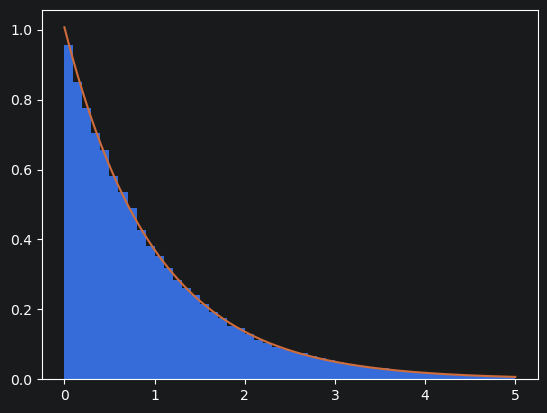

In [2]:
normalisation = 1-np.exp(-5)

def f(tau):
    return np.exp(-tau)/normalisation

df = pd.read_csv("../data/task4/histogram.csv")

plt.hist(df, bins=50, density=True, label="generated distribution")

tau_values = np.linspace(0, 5, 1000)
plt.plot(tau_values, f(tau_values), label="f_normalised(tau)")


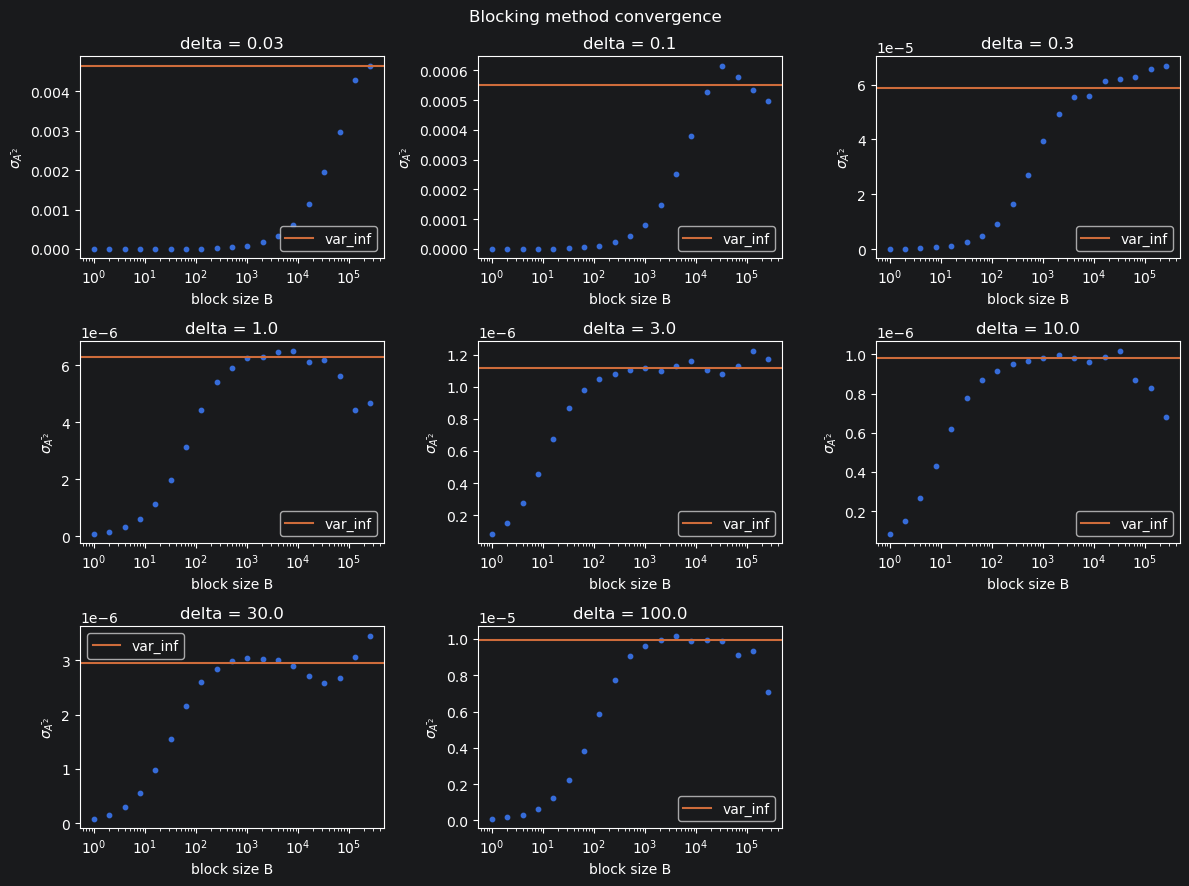

In [6]:
df = pd.read_csv("../data/task4/block_convergence.csv")
tau_autocorrelation_df = pd.read_csv("../data/task4/delta_values.csv").dropna()

deltas = sorted(tau_autocorrelation_df["delta"].unique())
n_cols = 3
n_rows = -(-len(deltas) // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows), squeeze=False)

for ax, delta in zip(axes.flat, deltas):
    df_delta = df[df["delta"] == delta]
    var_inf = tau_autocorrelation_df.loc[tau_autocorrelation_df["delta"] == delta, "var_inf"].iloc[0]

    ax.scatter(df_delta["B"], df_delta["error"], s=10)
    ax.set_xscale("log")
    ax.axhline(var_inf, color="C1", label="var_inf")
    ax.set_xlabel("block size B")
    ax.set_ylabel(r"$\sigma_{\bar{A^2}}$")
    ax.set_title(f"delta = {delta}")
    ax.legend()

for ax in axes.flat[len(deltas):]:
    ax.set_visible(False)

fig.suptitle("Blocking method convergence")
fig.tight_layout()


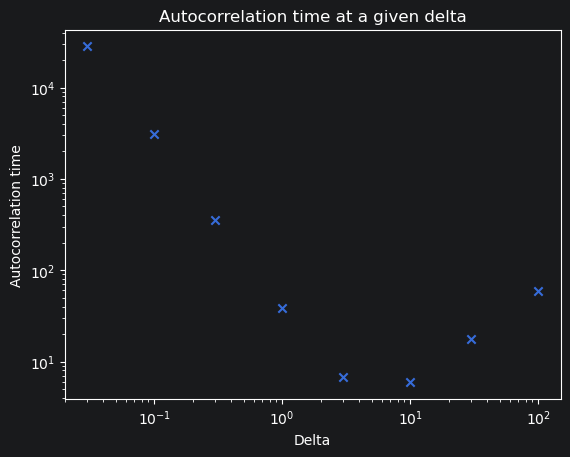

In [7]:
tau_autocorrelation_df = pd.read_csv("../data/task4/delta_values.csv").dropna()

plt.scatter(tau_autocorrelation_df["delta"], tau_autocorrelation_df["tao_int"], marker="x")

plt.xlabel("Delta")
plt.ylabel("Autocorrelation time")

plt.title("Autocorrelation time at a given delta")

plt.yscale("log")
plt.xscale("log")